In [19]:
import torch

In [20]:
model_path = '../models/rnn_seq2seq2.pt'

In [21]:
### Select device (GPU) ###

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'


print('Selected device:', device)

Selected device: cuda


In [22]:
import pandas as pd

### Reading data set ###

df = pd.read_csv('../data-sets/eng-nld.txt', sep='\t', header=None, usecols=[0, 1], names=['ENG', 'NLD'], dtype='string')
df.dropna()


print(df.info())
print()
print(df.sample())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76158 entries, 0 to 76157
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ENG     76158 non-null  string
 1   NLD     76158 non-null  string
dtypes: string(2)
memory usage: 1.2 MB
None

                         ENG                         NLD
19668  It surprised me, too.  Het heeft mij ook verrast.


In [23]:
import numpy as np
from nltk import word_tokenize

### Preprocessing ###

train_frac = 0.8
max_size = 15

sos_token = "<sos>"
eos_token = "<eos>"


# Tokenize
df['eng_tokens'] = df['ENG'].apply(lambda x: [sos_token] + word_tokenize(x.lower()) + [eos_token])
df['nld_tokens'] = df['NLD'].apply(lambda x: [sos_token] + word_tokenize(x.lower()) + [eos_token])

# Trim
df = df.drop(df[
    (df['eng_tokens'].map(len) > max_size) | 
    (df['nld_tokens'].map(len) > max_size)
].index)

# Split
df = df.sample(frac=1).reset_index(drop=True)
split = int(train_frac * len(df))

train_data = df.iloc[:split, :]
test_data  = df.iloc[split:, :]
test_data.reset_index(drop=True, inplace=True)


print('Total rows from file:', len(df))
print('Total rows of train data::', len(train_data))
train_data

Total rows from file: 74209
Total rows of train data:: 59367


,ENG,NLD,eng_tokens,nld_tokens
0,Tom told the whole story yesterday.,Tom vertelde gisteren het hele verhaal.,"[<sos>, tom, told, the, whole, story, yesterda...","[<sos>, tom, vertelde, gisteren, het, hele, ve..."
1,We drank a lot.,We dronken veel.,"[<sos>, we, drank, a, lot, ., <eos>]","[<sos>, we, dronken, veel, ., <eos>]"
2,You can rest.,Je kan uitrusten.,"[<sos>, you, can, rest, ., <eos>]","[<sos>, je, kan, uitrusten, ., <eos>]"
3,Ask your parents.,Vraag maar aan je ouders.,"[<sos>, ask, your, parents, ., <eos>]","[<sos>, vraag, maar, aan, je, ouders, ., <eos>]"
4,Tom said that he wished he hadn't hit Mary.,Tom zei dat hij wilde dat hij Mary niet had ge...,"[<sos>, tom, said, that, he, wished, he, had, ...","[<sos>, tom, zei, dat, hij, wilde, dat, hij, m..."
...,...,...,...,...
59362,I've just arrived at the station.,Ik ben pas aangekomen in het station.,"[<sos>, i, 've, just, arrived, at, the, statio...","[<sos>, ik, ben, pas, aangekomen, in, het, sta..."
59363,Tom felt sympathy for Mary.,Tom had medelijden met Mary.,"[<sos>, tom, felt, sympathy, for, mary, ., <eos>]","[<sos>, tom, had, medelijden, met, mary, ., <e..."
59364,Who won the election?,Wie heeft de verkiezingen gewonnen?,"[<sos>, who, won, the, election, ?, <eos>]","[<sos>, wie, heeft, de, verkiezingen, gewonnen..."
59365,Did you really say that to Tom?,Heb je dat echt tegen Tom gezegd?,"[<sos>, did, you, really, say, that, to, tom, ...","[<sos>, heb, je, dat, echt, tegen, tom, gezegd..."


In [24]:
import torchtext

min_freq  = 2
unk_token = '<unk>'
pad_token = '<pad>'

special_tokens = [unk_token, pad_token, sos_token, eos_token]


eng_vocab = torchtext.vocab.build_vocab_from_iterator(
    df['eng_tokens'],
    min_freq=min_freq,
    specials=special_tokens
)


nld_vocab = torchtext.vocab.build_vocab_from_iterator(
    df['nld_tokens'],
    min_freq=min_freq,
    specials=special_tokens
)

eng_vocab.set_default_index(eng_vocab[unk_token])
nld_vocab.set_default_index(nld_vocab[unk_token])


print('Unique tokens in \'eng_tokens\' column:', len(eng_vocab))
print('Unique tokens in \'nld_tokens\' column:', len(nld_vocab))

Unique tokens in 'eng_tokens' column: 6565
Unique tokens in 'nld_tokens' column: 8353


In [25]:
import random
import numpy as np

### Vectorize data set ###

eng_pad_index = eng_vocab[pad_token]
nld_pad_index = nld_vocab[pad_token]


def build_dataset(subset):
    X = np.zeros((len(subset), max_size), dtype=np.int32)
    Y = np.zeros((len(subset), max_size), dtype=np.int32)
        
    for ix, row in subset.iterrows():
        eng_ixs = eng_vocab.lookup_indices(row['eng_tokens'])
        eng_ixs = eng_ixs + [eng_pad_index] * (max_size - len(eng_ixs))

        nld_ixs = nld_vocab.lookup_indices(row['nld_tokens'])
        nld_ixs = nld_ixs + [nld_pad_index] * (max_size - len(nld_ixs))

        X[ix] = eng_ixs
        Y[ix] = nld_ixs

    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)

    return X, Y


Xtr, Ytr = build_dataset(train_data)
Xte, Yte = build_dataset(test_data)


print('Xtr shape:', Xtr.shape)
print()
ix = random.randint(0, len(Xtr))
print(Xtr[ix].tolist())
print(Ytr[ix].tolist())
print()
print(eng_vocab.lookup_tokens(Xtr[ix].tolist()))
print(nld_vocab.lookup_tokens(Ytr[ix].tolist()))


Xtr shape: torch.Size([59367, 15])

[2, 24, 623, 233, 0, 15, 827, 4, 3, 1, 1, 1, 1, 1, 1]
[2, 23, 1525, 244, 4719, 12, 902, 4, 3, 1, 1, 1, 1, 1, 1]

['<sos>', 'my', 'older', 'brother', '<unk>', 'that', 'company', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
['<sos>', 'mijn', 'oudere', 'broer', 'runt', 'dat', 'bedrijf', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


In [26]:
import torch.nn as nn

### Bidirection Encoder ###

class Encoder(nn.Module):

    def __init__(self, vocab_size, emb_dim, hidden_size, n_layers=1, dropout=0):
        super(Encoder, self).__init__()

        self.vocab_size  = vocab_size
        self.emb_dim     = emb_dim
        self.hidden_size = hidden_size
        self.n_layers    = n_layers

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.LSTM(emb_dim, hidden_size, n_layers, batch_first=True, dropout=dropout, bidirectional=True)
        self.dropout    = nn.Dropout(dropout)
        

    def forward(self, input):
        # input = [batch size, sequence length]

        embeddings = self.dropout(self.embeddings(input))
        # embeddings = [batch size, sequence length, embedding dim]

        _, (hidden, cell) = self.rnn(embeddings)
        # _      = [batch size, sequence length, 2 * hidden size]
        # hidden = [2 * n layers, batch size, hidden size]
        # cell   = [2 * n layers, batch size, hidden size]

        return hidden, cell

In [27]:
import torch.nn as nn

class Decoder(nn.Module):
    
    def __init__(self, vocab_size, emb_dim, hidden_size, n_layers=1, dropout=0):
        super(Decoder, self).__init__()

        self.vocab_size  = vocab_size
        self.emb_dim     = emb_dim
        self.hidden_size = hidden_size
        self.n_layers    = n_layers

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.LSTM(emb_dim, hidden_size * 2, n_layers, batch_first=True, dropout=dropout)
        self.fc         = nn.Linear(hidden_size * 2, vocab_size)
        self.dropout    = nn.Dropout(dropout)


    def forward(self, input, hidden, cell):
        # input  = [batch size]
        # hidden = [n layers, batch size, 2 * hidden size]
        # cell   = [n layers, batch size, 2 * hidden size]

        input = input.unsqueeze(1)
        # input = [batch size, 1]

        embeddings = self.dropout(self.embeddings(input))
        # embeddings = [batch size, 1, embedding dim]

        output, (hidden, cell) = self.rnn(embeddings, (hidden, cell))
        # output = [batch size, 1, hidden size]
        # hidden = [n layers, batch size, hidden size]
        # cell   = [n layers, batch size, hidden size]

        prediction = self.fc(output.squeeze(1))
        # prediction = [batch size, vocab size]

        return prediction, hidden, cell

In [29]:
import re
import torch.nn as nn

class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder):
        super().__init__()

        assert encoder.hidden_size == decoder.hidden_size, 'Encoder and decoder hidden size should match'

        self.encoder = encoder
        self.decoder = decoder
    
    
    def forward(self, source, target, teacher_force_ratio=0):
        # source = [batch size, sequence length]
        # target = [batch size, sequence length]

        batch_size        = target.shape[0]
        sequence_length   = target.shape[1]
        target_vocab_size = self.decoder.vocab_size

        outputs = torch.zeros(sequence_length, batch_size, target_vocab_size).to(device)
        # outputs = [sequence length, batch size, vocab length]  

        # last hidden state of the encoder is used as the initial hidden state of the decoder
        hidden, cell = self.encoder(source)
        # hidden = [2 * n layers, batch size, hidden size]
        # cell   = [2 * n layers, batch size, hidden size]

        hidden = hidden.view(self.encoder.n_layers, 2, batch_size, hidden.shape[2])
        hidden = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)
        cell   = cell.view(self.encoder.n_layers, 2, batch_size, cell.shape[2])
        cell   = torch.cat((cell[:, 0, :, :], cell[:, 1, :, :]), dim=2)
        # hidden = [n layers, batch size, 2 * hidden size]
        # cell   = [n layers, batch size, 2 * hidden size]

        # first input to the decoder is the <sos> tokens
        input = target[:, 0]
        # input = [batch size]
        
        # Decode
        for i in range(1, sequence_length):
            output, hidden, cell = self.decoder(input, hidden, cell)
            # output = [batch size, sequence length, vocab size]

            outputs[i] = output
            
            top1 = torch.argmax(output, dim=1)
            input = target[:, i] if random.random() < teacher_force_ratio else top1
        
        outputs = outputs.permute(1, 2, 0)
        # outputs = [batch size, vocab size, sequence length]
        
        return outputs


    @torch.inference_mode()
    def translate(self, sentence, max_output_length=20):
        self.eval()
        
        nld_sos_index = nld_vocab[sos_token]
        nld_eos_index = nld_vocab[eos_token]

        tokens = [sos_token] + word_tokenize(sentence.lower()) + [eos_token]
        ixs = eng_vocab.lookup_indices(tokens)
        tensor = torch.tensor(ixs).unsqueeze(0).to(device)

        # Encode English sentence
        hidden, cell = self.encoder(tensor)

        hidden = hidden.view(self.encoder.n_layers, 2, 1, hidden.shape[2])
        hidden = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)
        cell   = cell.view(self.encoder.n_layers, 2, 1, cell.shape[2])
        cell   = torch.cat((cell[:, 0, :, :], cell[:, 1, :, :]), dim=2)

        # Decode to Dutch
        indices = [nld_sos_index]
        for _ in range(max_output_length):
            inputs_tensor = torch.tensor(indices[-1]).unsqueeze(0).to(device)
            output, hidden, cell = self.decoder(inputs_tensor, hidden, cell)
            prediction = torch.argmax(output, dim=1).item()
            indices.append(prediction)
            if(prediction == nld_eos_index):
                break
        
        tokens = nld_vocab.lookup_tokens(indices)
        tokens = [t for t in tokens if t not in (eos_token, sos_token)]
        sentence = ' '.join(tokens).capitalize()
        sentence = re.sub(r'\s+([.,!?])', r'\1', sentence)

        return sentence

In [30]:
emb_dim     = 300
hidden_size = 512
n_layers    =   2
dropout     = 0.5

encoder = Encoder(len(eng_vocab), emb_dim, hidden_size, n_layers=n_layers, dropout=dropout)
decoder = Decoder(len(nld_vocab), emb_dim, hidden_size, n_layers=n_layers, dropout=dropout)
model   = Seq2Seq(encoder, decoder).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 36499113


In [31]:
import os.path

if os.path.isfile(model_path):
    print('Found saved model on', model_path)
    model.load_state_dict(torch.load(model_path))

Found saved model on ../models/rnn_seq2seq2.pt


In [14]:
lr = 0.0001


# Gradually lower forced teaching ratio throughout the training
def forced_teaching_ratio(current_epoch, total_epochs, initial_ratio=0.9, final_ratio=0):
    progress = current_epoch / total_epochs
    return initial_ratio - (initial_ratio - final_ratio) * progress

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [15]:
from tqdm import trange
import torch.nn.functional as F

### Train network ###

epochs              = 100000
batch_size          =     64
eval_batch_size     =   6400

epoch_count       = []
ratio_values      = []
train_loss_values = []
test_loss_values  = []
gradients_norm    = []


for epoch in trange(epochs):
    model.train()


    ratio = forced_teaching_ratio(epoch, epochs)

    # Sample mini-batch and send to gpu
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)

    output = model(Xb, Yb, ratio) # Do the forward pass
    loss = criterion(output, Yb)  # Calculate the loss
    optimizer.zero_grad()         # Reset parameters
    loss.backward()               # Backpropagation
    optimizer.step()              # Update parameters


    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):

        gradients_norm.append(
            torch.tensor(
                [torch.norm(param.grad).item() for param in model.parameters() if param.grad is not None]
            ).norm().item())
        
        inputs = torch.zeros((eval_batch_size, max_size), dtype=torch.long).to(device)
        inputs[:, 0] = nld_vocab[sos_token]

        model.eval()
        with torch.inference_mode():
        
            # Sample larger train-batch
            ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,))
            Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)
            
            outputs = model(Xb, inputs)
            loss = F.cross_entropy(outputs, Yb)

            # Sample larger test-batch
            ix = torch.randint(0, Xte.shape[0], (eval_batch_size,))
            Xb, Yb = Xte[ix].to(device), Yte[ix].to(device)

            outputs = model(Xb, inputs)
            test_loss = F.cross_entropy(outputs, Yb)
            
            # Log data
            epoch_count.append(epoch)
            ratio_values.append(ratio)
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())


# Print final results
print()
print('Final training loss:', round(loss.item(), 3))
print('Final test loss:    ', round(test_loss.item(), 3))

100%|██████████| 100000/100000 [1:45:49<00:00, 15.75it/s] 


Final training loss: 0.7
Final test loss:     2.163


In [16]:
torch.save(model.state_dict(), model_path)

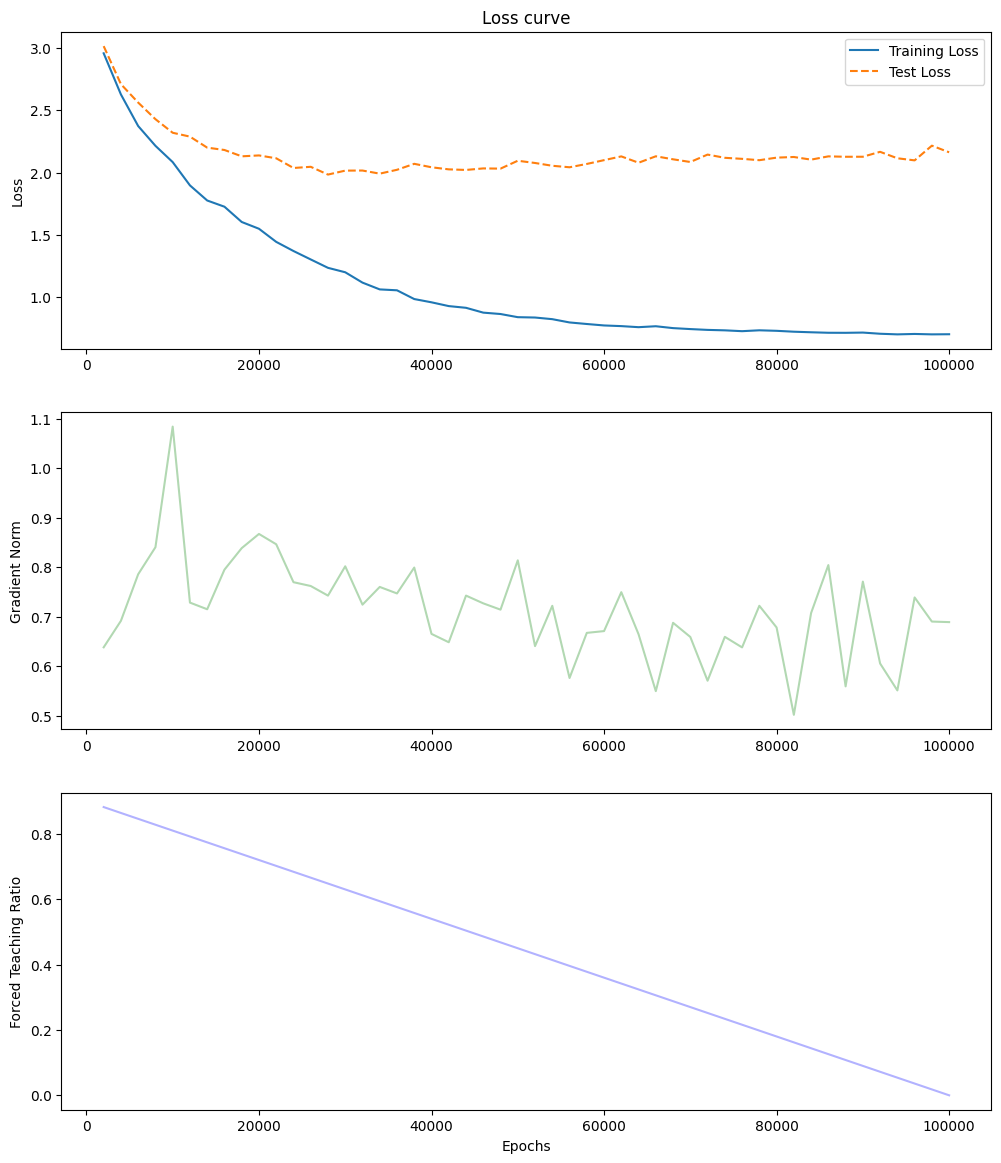

In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14))

# Plot training and test loss on the first subplot
ax1.plot(epoch_count, train_loss_values, label='Training Loss')
ax1.plot(epoch_count, test_loss_values, label='Test Loss', linestyle='--')
ax3.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss curve')
ax1.legend(loc='upper right')

# Plot gradient norm on the second subplot
ax2.plot(epoch_count, gradients_norm, 'g', alpha=0.3)
ax3.set_xlabel('Epochs')
ax2.set_ylabel('Gradient Norm')

# Plot forced teaching ratio decay on the third subplot
ax3.plot(epoch_count, ratio_values, 'b', alpha=0.3)
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Forced Teaching Ratio')

plt.show()

In [32]:
### Use model ###

print(model.translate('I\'m very happy.'))
print(model.translate('He\'s very sad.'))
print(model.translate('That man is wearing a white shirt.'))
print(model.translate('He\'s afraid of spiders.'))
print(model.translate('He\'s going home to his wife.'))
print(model.translate('Those guys are walking to work.'))
print(model.translate('I\'m not going with you today.'))
print(model.translate('My girlfriend will not come over tomorrow.'))

Ik ben erg blij.
Hij is erg, heel ziek.
Die man draagt een een <unk>.
Hij is bang voor spinnen.
Hij gaat naar de verenigde van zijn vrouw.
Die mensen zijn bezig om werk te stappen.
Ik ga niet vandaag met je..
Mijn ouders zal morgen niet langs.
